CARICO I DATI

In [2]:
# %%
# --- CELLA 1: SETUP E CARICAMENTO DATI ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 1. Caricamento Dati
print("📂 Caricamento dati...")

try:
    # A. News
    df_news = pd.read_csv('funzione_news_n(t)_FINALE.csv', index_col='created_at', parse_dates=True)
    if df_news.index.tz is None: df_news.index = df_news.index.tz_localize('UTC')
    else: df_news.index = df_news.index.tz_convert('UTC')
    n_t = df_news['n_t_finale']

    # B. Prezzi Reali
    nome_file_prezzi = 'prezzi_puliti_MARZO_APRILE_2.csv' # Verifica il nome del file
    df_prezzi_raw = pd.read_csv(nome_file_prezzi, index_col='open_time', parse_dates=True) # Verifica 'open_time'
    if df_prezzi_raw.index.tz is None: df_prezzi_raw.index = df_prezzi_raw.index.tz_localize('UTC')
    else: df_prezzi_raw.index = df_prezzi_raw.index.tz_convert('UTC')
    
    # Resampling a 10 minuti per allineare con le news
    # Usa 'price' o 'close' a seconda del tuo CSV
    col_prezzo = 'price' if 'price' in df_prezzi_raw.columns else 'close'
    prezzi_reali = df_prezzi_raw[col_prezzo].resample('10min').mean().dropna()

    print(f"✅ Dati caricati. News: {len(n_t)}, Prezzi: {len(prezzi_reali)}")

except FileNotFoundError as e:
    print(f"❌ ERRORE FILE: {e}")
    assert False
except KeyError as e:
    print(f"❌ ERRORE COLONNA: {e}")
    assert False

# 2. Allineamento Temporale Esatto
# Prendiamo solo l'intersezione delle date per evitare errori di lunghezza
common_index = n_t.index.intersection(prezzi_reali.index)
n_t_sim = n_t.loc[common_index]
prezzi_reali_sim = prezzi_reali.loc[common_index]

print(f"✅ Setup pronto. Periodo simulazione: {common_index[0]} -> {common_index[-1]}")
print(f"   Step totali: {len(common_index)}")

📂 Caricamento dati...
✅ Dati caricati. News: 8496, Prezzi: 8784
✅ Setup pronto. Periodo simulazione: 2021-03-01 00:00:00+00:00 -> 2021-04-28 23:50:00+00:00
   Step totali: 8496


✅ Simulazione: 2021-04-12 00:00:00+00:00 -> 2021-04-21 00:00:00+00:00
   Freno attivo su finestra di 60 minuti (6 step)
🚀 Calcolo in corso...


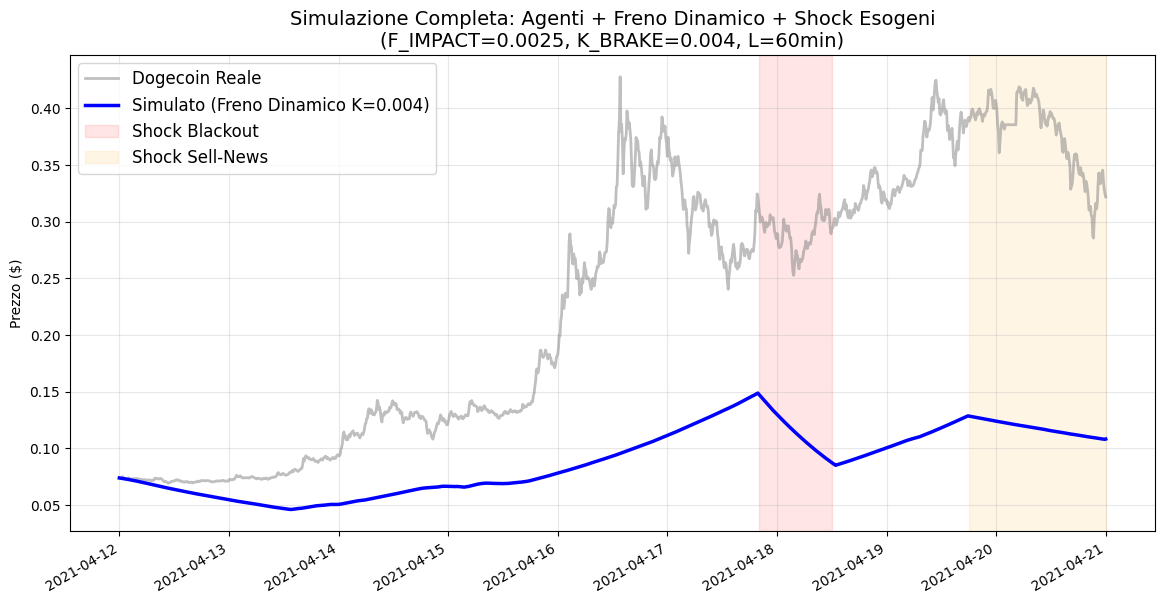

In [3]:
# %%
# --- SIMULAZIONE COMPLETA: FRENO DINAMICO (Profit Taking) + SHOCK ESOGENI ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 1. PARAMETRI AGENTI
N_AGENTI = 1000
MU = 0.5              # Reattività agenti
ALPHA = 0.05          # Influenza sociale
GAMMA_BAR = 8.0       # Influencer
SIGMA_NOISE = 0.05    
THETA = 4.0           

# 2. PARAMETRI MERCATO & FRENO
F_IMPACT = 0.0025     # (kappa) Spinta della domanda (fisso come richiesto)

# Nuovi parametri Freno Dinamico
K_BRAKE = 0.004      # (K) Forza del ritorno alla media (range 0.003-0.005)
WINDOW_MINUTES = 60   # (L) Finestra media mobile in minuti
STEP_RESOLUTION = 10  # Risoluzione dei tuoi dati (10 min)
WINDOW_STEPS = int(WINDOW_MINUTES / STEP_RESOLUTION) # L in step (60/10 = 6 step)

# 3. DEFINIZIONE SHOCK ESOGENI (Blackout & Sell News)
def get_external_shock(current_time):
    ts = pd.to_datetime(current_time)
    shock = 0.0
    
    # A. Blackout Cina (17-18 Aprile)
    if (ts.day == 17 and ts.hour >= 20) or (ts.day == 18 and ts.hour <= 12):
        shock = -0.008 
        
    # B. Sell the News (19-20 Aprile)
    elif (ts.day == 19 and ts.hour >= 18) or (ts.day == 20):
        shock = -0.0035
        
    return shock

# 4. PREPARAZIONE DATI
START_DATE = '2021-04-12 00:00:00+00:00'
END_DATE = '2021-04-21 00:00:00+00:00'

try:
    n_t_sim = n_t.loc[START_DATE:END_DATE]
    prezzi_reali_sim = prezzi_reali.loc[START_DATE:END_DATE]
    print(f"✅ Simulazione: {START_DATE} -> {END_DATE}")
    print(f"   Freno attivo su finestra di {WINDOW_MINUTES} minuti ({WINDOW_STEPS} step)")
except:
    common = n_t.index.intersection(prezzi_reali.index)
    n_t_sim = n_t.loc[common]
    prezzi_reali_sim = prezzi_reali.loc[common]

# 5. INIZIALIZZAZIONE
G = nx.watts_strogatz_graph(N_AGENTI, 4, 0.1)
gradi = dict(G.degree())
influencer_node = max(gradi, key=gradi.get)
gamma_i = np.full(N_AGENTI, 1.0)
gamma_i[influencer_node] = GAMMA_BAR

opinioni = np.random.uniform(-0.1, 0.1, N_AGENTI)
log_prezzo = np.log(prezzi_reali_sim.iloc[0])
storico_prezzo_simulato = []

# Buffer per la media mobile (inizializzato col prezzo di partenza)
history_log_prezzi = [log_prezzo] * (WINDOW_STEPS + 1)

print("🚀 Calcolo in corso...")

# --- CICLO SIMULAZIONE ---
for t, segnale_news in n_t_sim.items():
    
    # A. Dinamica Agenti
    opinioni_prev = opinioni.copy()
    opinione_media = np.mean(opinioni_prev)
    termine_sociale = ALPHA * (opinione_media - opinioni_prev)
    termine_news = gamma_i * segnale_news
    rumore = np.random.normal(0, SIGMA_NOISE, N_AGENTI)
    
    S_prime = termine_sociale + termine_news + rumore
    opinioni = (1 - MU) * opinioni_prev + MU * S_prime
    
    # B. Domanda Aggregata D(t)
    azioni = np.tanh(THETA * opinioni)
    domanda_netta = np.mean(azioni)
    
    # C. Calcolo del FRENO DINAMICO
    # 1. Calcola la Media Mobile (MA_L) sugli ultimi L step
    ma_L = np.mean(history_log_prezzi[-WINDOW_STEPS:])
    
    # 2. Termine Freno: K * (Prezzo_Attuale - Media)
    # Se il prezzo corre troppo sopra la media, questo termine diventa positivo e viene sottratto
    distanza_da_media = log_prezzo - ma_L
    termine_freno = K_BRAKE * distanza_da_media
    
    # D. Calcolo SHOCK ESOGENO
    shock_esogeno = get_external_shock(t)
    
    # E. Aggiornamento Prezzo Totale
    # Equazione: p(t+1) = p(t) + [Agente] - [Freno] + [Shock]
    rendimento = (F_IMPACT * domanda_netta) - termine_freno + shock_esogeno + np.random.normal(0, 0.0002)
    
    log_prezzo = log_prezzo + rendimento
    
    # Aggiornamento storici
    history_log_prezzi.append(log_prezzo)
    storico_prezzo_simulato.append(np.exp(log_prezzo))

# 6. GRAFICO
df_res = pd.DataFrame({
    'Reale': prezzi_reali_sim,
    'Simulato': storico_prezzo_simulato
}, index=n_t_sim.index)

plt.figure(figsize=(14, 7))
plt.plot(df_res.index, df_res['Reale'], label='Dogecoin Reale', color='gray', alpha=0.5, linewidth=2)
plt.plot(df_res.index, df_res['Simulato'], label=f'Simulato (Freno Dinamico K={K_BRAKE})', color='blue', linewidth=2.5)

# Evidenzia shock
plt.axvspan('2021-04-17 20:00', '2021-04-18 12:00', color='red', alpha=0.1, label='Shock Blackout')
plt.axvspan('2021-04-19 18:00', '2021-04-21 00:00', color='orange', alpha=0.1, label='Shock Sell-News')

plt.title(f"Simulazione Completa: Agenti + Freno Dinamico + Shock Esogeni\n(F_IMPACT={F_IMPACT}, K_BRAKE={K_BRAKE}, L={WINDOW_MINUTES}min)", fontsize=14)
plt.ylabel("Prezzo ($)")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()